In [1]:
import numpy as np
from scipy.sparse import diags
from scipy.linalg import eigh
import pennylane as qml
from pennylane import numpy as pnp
from tqdm import tqdm

In [2]:
###   ###   ###   constants   ###   ###   ###
hbar = c = 1  # as god intended
mass = 50  # example
omega = 1  # example

n = 128  # number of elements, same as before

In [3]:
###   ###   ###   handy functions   ###   ###   ###
def harmonic_oscillator_potential(x,
                                  omega=omega,
                                  m=mass):
    V_vector = 0.5 * m * omega ** 2 * x ** 2  # calculate the potential
    V_matrix = diags(V_vector).toarray()  # operator-ify that vector
    return V_matrix


###   ###   ###   more problem setup   ###   ###   ###
x, dx = np.linspace(-1, 1, n, retstep=True)  # real-space (it's where it's at!)
# finite differencing 2nd derivative (good enough for toy problem):
d2 = diags([1., -2., 1.], [-1, 0, 1], shape=(n, n)).toarray() / (dx**2)
T = -0.5 / mass * d2
V = harmonic_oscillator_potential(x)
H_matrix = T + V

In [4]:
###   ###   ### Convert the Hamiltonian matrix to a Pauli operators   ###   ###   ###
n_qubits = int(np.log2(n))     # log2(128) = 7 for this example
print(f"Converting {n}x{n} Hamiltonian to Pauli operators ({n_qubits} qubits)...")
# The wire_order argument specifies the qubit labels for the matrix
hamiltonian = qml.pauli.pauli_decompose(H_matrix, wire_order=range(n_qubits))
print(f"Number of Pauli terms: {len(hamiltonian.ops)}")

Converting 128x128 Hamiltonian to Pauli operators (7 qubits)...
Number of Pauli terms: 149


In [5]:
###   ###   ###   Define the ansatz (variational circuit) for 7 qubits   ###   ###   ###
dev = qml.device('default.qubit', wires=n_qubits)

# Choose a simple hardware-efficient ansatz with 2 repetitions
def ansatz(params):
    # Initialize all qubits in |0> (no Hartree-Fock state needed for this problem)
    # Apply layers of single-qubit rotations and CNOTs
    for layer in range(2):
        for i in range(n_qubits):
            qml.RY(params[layer, i, 0], wires=i)
            qml.RZ(params[layer, i, 1], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
    # Optionally add a final layer of rotations
    for i in range(n_qubits):
        qml.RY(params[2, i, 0], wires=i)
        qml.RZ(params[2, i, 1], wires=i)

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(hamiltonian)

In [ ]:
###   ###   ###   Set up the optimization   ###   ###   ###
# Number of parameters: (2 layers * 2 rotations per qubit) + (final layer * 2) = 3 layers * 7 qubits * 2 = 42
np.random.seed(17)
# init_params = pnp.random.random((3, n_qubits, 2), requires_grad=True)  # random start
init_params = pnp.zeros((3, n_qubits, 2), requires_grad=True)  # start from all zeros

step_size = 0.03
# optimizer = qml.GradientDescentOptimizer(stepsize=step_size)  # this gave bad convergence
optimizer = qml.AdamOptimizer(stepsize=step_size)  # this gave "better" convergence

print("\nStarting VQE optimization...")
max_iter = 1000
iter_energies = []
params = init_params
for i in tqdm(range(max_iter)):
    params, energy = optimizer.step_and_cost(cost_fn, params)
    iter_energies.append(energy)

###   ###   ###   Compare with exact result   ###   ###   ###
exact_energy = 0.5
print("\n--- Final Results ---")
print(f"Exact ground state energy (known result): {exact_energy:.8f}")
print(f"VQE estimated ground state energy: {energy:.8f}")
print(f"Error: {abs(energy - exact_energy):.2e}")


Starting VQE optimization...


100%|██████████| 1000/1000 [03:07<00:00,  5.33it/s]


--- Final Results ---
Exact ground state energy (known result): 0.50000000
VQE estimated ground state energy: 1.95544087
Error: 1.46e+00


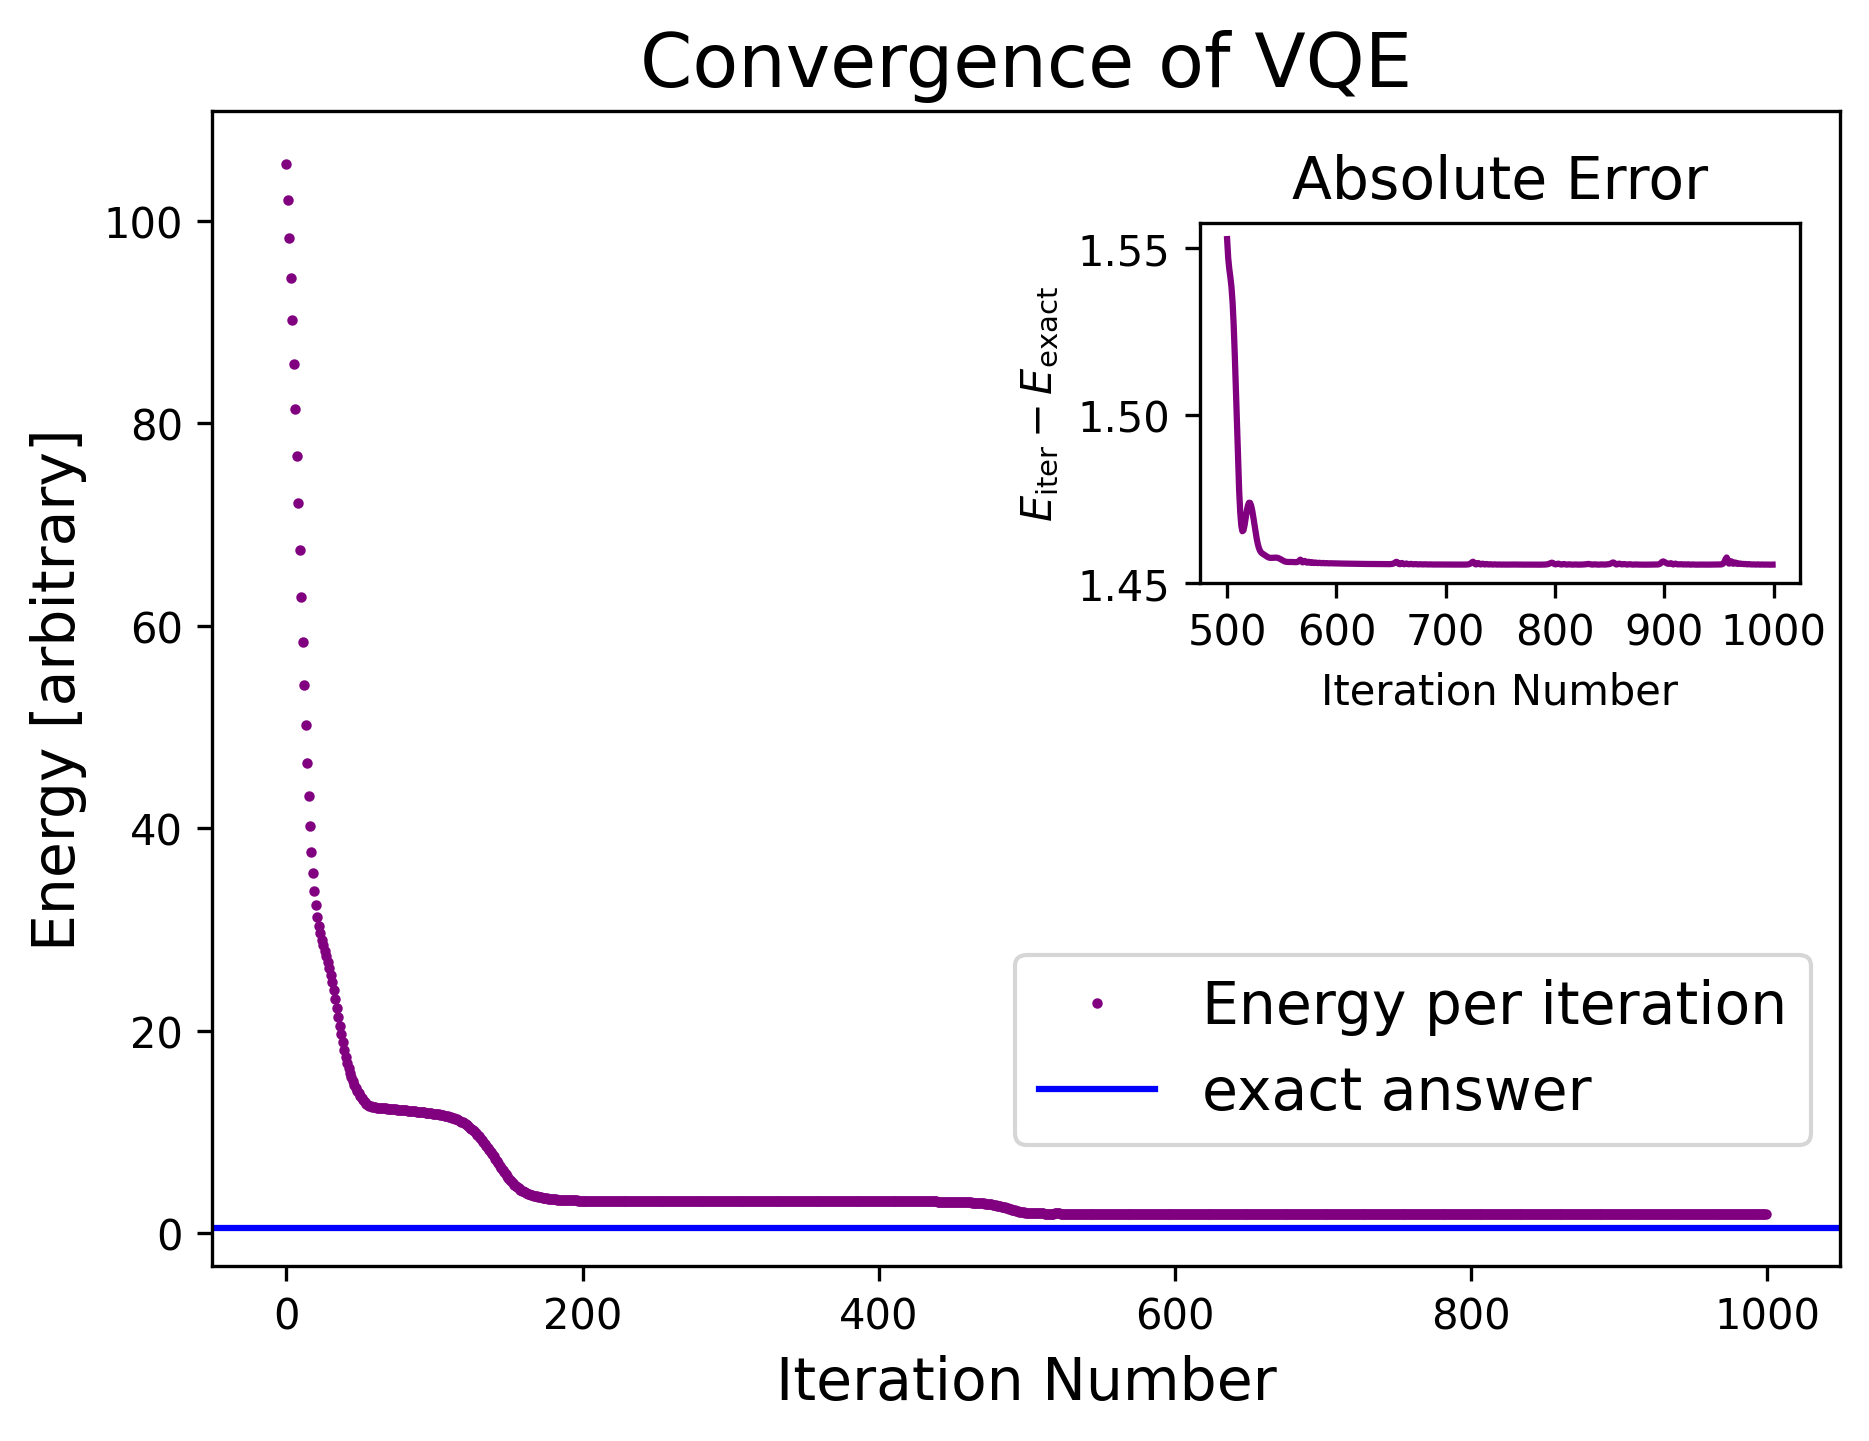

In [91]:
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
plt.style.use("default")

fig, ax = plt.subplots(1, 1, dpi=300, figsize=(7, 5))

ax.set_title("Convergence of VQE", fontsize=18)

ax.plot(iter_energies, marker=".", markersize=3, color="purple", linestyle="none", label="Energy per iteration")
ax.axhline(0.5, color="blue", label="exact answer")


# error plot
inset_error = inset_axes(ax,
                         width=2.0,
                         height=1.2,
                         loc="upper center",
                         bbox_to_anchor=(1550, 1250),  # jesus christ
                         borderpad=1)
inset_error.set_title("Absolute Error", fontsize=14)
inset_error.plot(np.asarray(iter_energies[500:]) - 0.5, color="purple")
inset_error.set_xlabel("Iteration Number")
# inset_error.set_xlim(500, 1000)
inset_error.set_xticks([0, 100, 200, 300, 400, 500], [500, 600, 700, 800, 900, 1000])
inset_error.set_ylabel(r"$E_{\rm{iter}} - E_{\rm{exact}}$")
# inset_error.set_yscale("log")
inset_error.set_yticks([1.45, 1.5, 1.55])
# inset_error.set_ylim(1.3, 2)

ax.set_xlabel("Iteration Number", fontsize=14)
ax.set_ylabel("Energy [arbitrary]", fontsize=14)
ax.legend(fontsize=14, loc="lower right", bbox_to_anchor=(1, 0.08))
# plt.tight_layout()
plt.savefig("VQE_result.png")
plt.show()

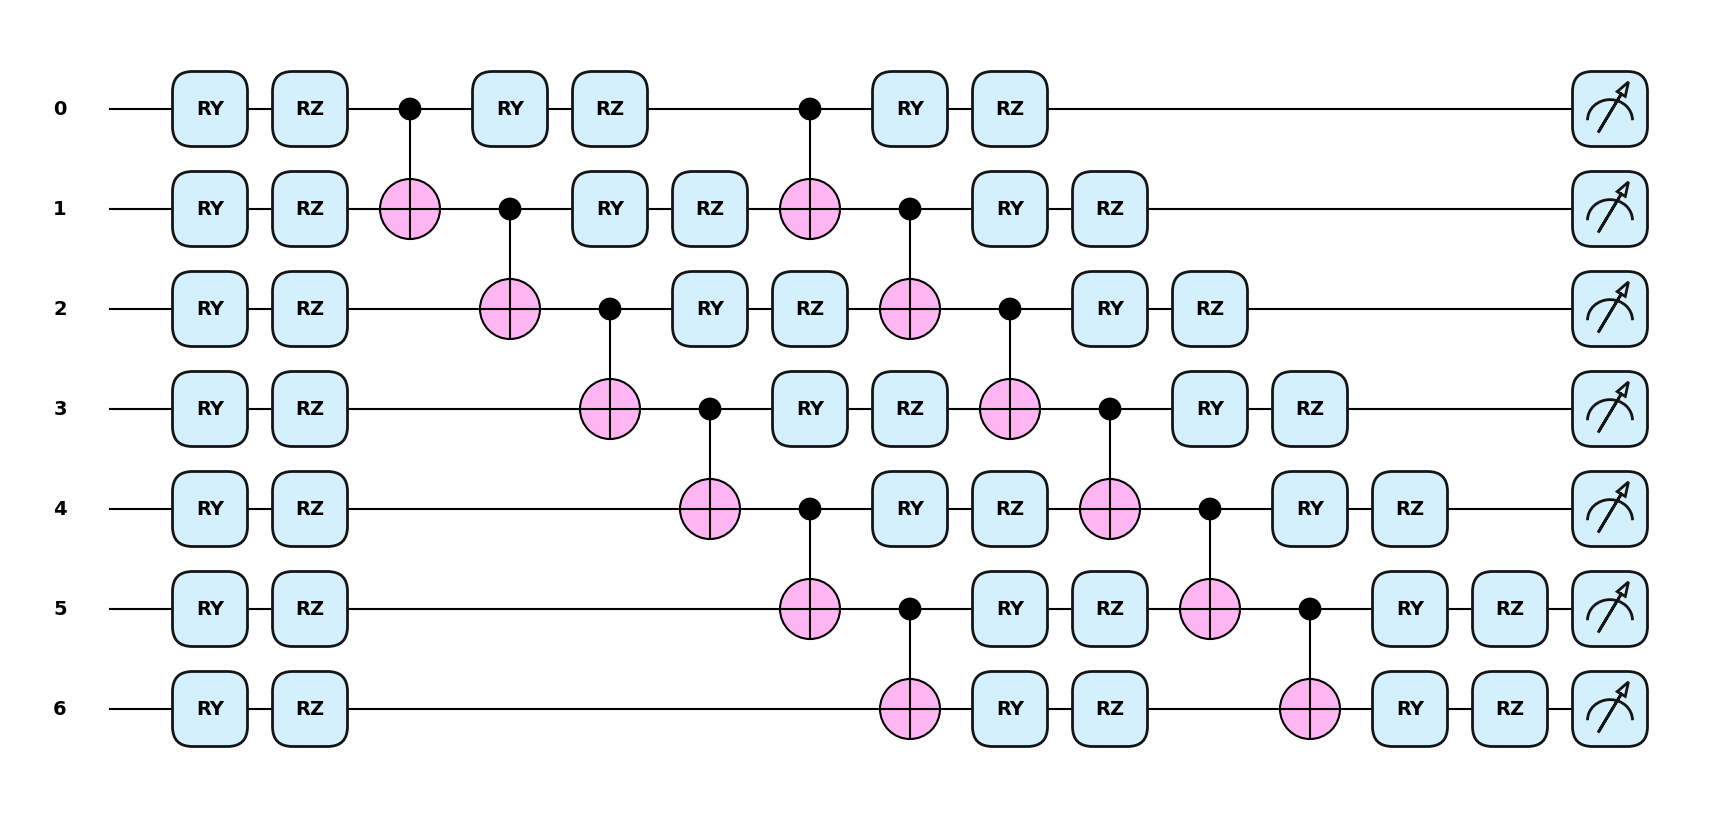

In [92]:
# Create a QNode with the same ansatz and device but using the initial parameters
@qml.qnode(dev)
def draw_circuit(params):
    ansatz(params)
    return qml.state()

# Draw the circuit
fig, ax = qml.draw_mpl(draw_circuit, style="pennylane", dpi=300)(init_params)
plt.savefig("circuit_diagram.png")
plt.show()